# Pandas 数据处理

In [1]:
import pandas as pd
import numpy as np

## 数据IO操作

In [73]:
fp = open('csv文件.csv', 'r', encoding='utf-8', errors='ignore')

# fp.read()

# fp.close()

In [74]:
pd.read_csv(fp, sep='\s+')

,lucy,19,北京
0,mery,20,上海
1,tom,22,北京


In [16]:
with open('csv文件.csv', 'r', encoding='utf-8') as fp:
    fp.read()

In [ ]:
pandas IO操作主要是读取有特定格式的文件

pd.read_csv()

In [21]:
pd.read_csv('csv文件.csv', sep=',', header=None, index_col=0)

,1,2
0,,
lucy,19,北京
mery,20,上海
tom,22,北京


In [30]:
pd.read_csv('csv文件.csv', sep=',', header=None)

,0,1,2
0,lucy,19,北京
1,mery,20,上海
2,tom,22,北京


pd.read_table()

In [34]:
pd.read_table('txt文件.txt', header=None, sep=' ', index_col=0)

,1,2
0,,
lucy,19,北京
mery,20,上海
tom,22,北京


In [41]:
pd.read_csv('txt文件.txt', sep=' ', header=None)

,0,1,2
0,lucy,19,北京
1,mery,20,上海
2,tom,22,北京


In [46]:
pd.read_csv('csv文件.csv', sep='-')

,lucy,19,北京
0,mery,20,上海
1,tom,22,北京


In [50]:
pd.read_csv('csv文件.csv', sep='\s+')

,lucy,19,北京
0,mery,20,上海
1,tom,22,北京


excel读取

In [60]:
data = pd.read_excel('excel文件.xlsx', header=None, names=['姓名','年龄','地址'], sheet_name='Sheet1')

In [63]:
data.to_excel('m_data.xlsx')

In [64]:
data.to_csv('m_data.csv')

## 数据探索

describe() info() head() tail() sample()

In [76]:
df = pd.DataFrame(data=np.random.randint(0, 10000, size=(10000, 4)), columns=list('ABCD'))
df

,A,B,C,D
0,5704,3316,3565,134
1,7190,658,9865,9878
2,8015,814,6613,3900
3,5400,3053,2374,5134
4,1715,629,757,7292
...,...,...,...,...
9995,7620,6070,885,2434
9996,4032,4924,3696,5509
9997,3126,280,4538,1852
9998,5841,8733,5410,5313


In [87]:
df.describe(percentiles=[ 0.99]).T

,count,mean,std,min,50%,99%,max
A,10000.0,5033.5774,2868.870937,0.0,5058.0,9885.00,9998.0
B,10000.0,4987.4635,2882.674383,0.0,4963.0,9898.02,9999.0
C,10000.0,4936.8835,2894.134757,0.0,4874.5,9902.00,9999.0
D,10000.0,4992.9394,2857.208838,0.0,4980.0,9911.00,9999.0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
A    10000 non-null int32
B    10000 non-null int32
C    10000 non-null int32
D    10000 non-null int32
dtypes: int32(4)
memory usage: 156.4 KB


In [85]:
df.tail(n=2)

,A,B,C,D
9998,5841,8733,5410,5313
9999,700,3847,5162,9202


In [86]:
df.sample(n=10)

,A,B,C,D
8067,3520,6727,576,1189
3976,8606,9556,6136,8246
8696,3146,1598,7425,9587
5629,6419,8223,8577,3667
645,9459,6188,3082,5990
9614,5919,3136,7236,7347
3396,5500,8981,9027,6568
611,4107,8028,9398,5951
3166,6802,7189,7966,1007
8176,6816,5389,7416,8833


## 空值处理

In [89]:
type(None)

NoneType

In [91]:
type(np.nan)

float

In [92]:
def get_sum(x):
    return x.sum()

In [93]:
data1 = np.arange(1000000, dtype=object)

In [96]:
%timeit get_sum(data1)

23.2 ms ± 708 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [97]:
data2 = np.arange(1000000, dtype=np.float)

In [98]:
%timeit get_sum(data2)

1.21 ms ± 62.9 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
object 运算效率 低于 float

### None

None是Python自带的，其类型为python object。因此，None不能参与到任何计算中。

object类型的运算要比int类型的运算慢得多

### np.nan（NaN）

np.nan是浮点类型，能参与到计算中。但计算的结果总是NaN。

在numpy中，可以使用np.nanxxx()函数来计算nan，此时视nan为0。

### pandas自动把None处理成np.nan

In [99]:
df = pd.DataFrame(data=np.random.randint(0, 10, size=(10, 2)), columns=['A','B'])
df

,A,B
0,5,1
1,2,0
2,9,6
3,2,8
4,5,8
5,4,3
6,4,1
7,5,5
8,0,7
9,0,6


In [101]:
df.loc[2] = None

In [103]:
# numpy 提供第一个常量，用于表达空值，是一个float

# NaN（not a number)  符号，不是一个量， pandas对象中，所有的np.nan  None 显示的时候，都是以NaN显示
# NaT (not a time)
np.nan

nan

In [105]:
a = np.nan

In [102]:
df

,A,B
0,5.0,1.0
1,2.0,0.0
2,NaN,NaN
3,2.0,8.0
4,5.0,8.0
5,4.0,3.0
6,4.0,1.0
7,5.0,5.0
8,0.0,7.0
9,0.0,6.0


In [107]:
df.loc[2,'A'] # np.nan

nan

In [109]:
df

,A,B
0,5.0,1.0
1,2.0,0.0
2,NaN,NaN
3,2.0,8.0
4,5.0,8.0
5,4.0,3.0
6,4.0,1.0
7,5.0,5.0
8,0.0,7.0
9,0.0,6.0


In [114]:
l_data = [None, 1, 2, 3.14]

arr = np.array(l_data)

pd.Series(data=arr)

0     NaN
1    1.00
2    2.00
3    3.14
dtype: float64

### 空值查找

isnull()  notnull()

In [2]:
df = pd.DataFrame(data=np.random.random(size=(10, 4)), columns=list('ABCD'))
df

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
2,0.074586,0.522079,0.723573,0.008140
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,0.121368,0.427351,0.036945
5,0.888940,0.932362,0.494705,0.589470
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415
9,0.372095,0.228509,0.150183,0.720072


In [3]:
df.loc[2] = np.nan
df.loc[4, 'B'] = np.nan
df.loc[5, 'D'] = np.nan
df.loc[9, ['A','B']] = np.nan
df

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
2,NaN,NaN,NaN,NaN
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,NaN,0.427351,0.036945
5,0.888940,0.932362,0.494705,NaN
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415
9,NaN,NaN,0.150183,0.720072


In [123]:
# 查看一个bool列表中， 是否存在至少一个True
np.array([False, False, False]).any()

False

In [126]:
# 查看一个bool列表中， 是否存全为True
np.array([True, False, True]).all()

False

In [127]:
# 默认列方向的any操作
df.isnull().any()

A    True
B    True
C    True
D    True
dtype: bool

In [130]:
df

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,NaN,NaN,NaN,NaN
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,NaN,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,NaN,NaN,0.905542,0.187831


In [129]:
df.isnull().any(axis=1)

0    False
1    False
2     True
3    False
4     True
5     True
6    False
7    False
8    False
9     True
dtype: bool

In [131]:
# 可以找出所有包含至少一个空值的行
df.loc[df.isnull().any(axis=1)]

,A,B,C,D
2,NaN,NaN,NaN,NaN
4,0.295703,NaN,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
9,NaN,NaN,0.905542,0.187831


In [ ]:
# 找出所有至少包含一个空值的列？？

In [135]:
# 找出全都不为空的行
df.loc[df.notnull().all(axis=1)]

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
3,0.321058,0.541224,0.456106,0.680896
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585


In [ ]:
True: 1
False: 0

In [141]:
float(True)

1.0

In [144]:
np.array([True, True, False]).astype(np.float)

array([1., 1., 0.])

In [148]:
np.array([True, True, False]).mean()

0.6666666666666666

In [149]:
# 查看某一【列】的空值占比
df.isnull().mean()

A    0.2
B    0.3
C    0.1
D    0.2
dtype: float64

In [ ]:
列字段是不能轻易删除的

### 空值填充

fillna()

In [151]:
# 整个表格中的统一填充方法
df.fillna(value=0)

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,0.000000,0.000000,0.000000,0.000000
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,0.000000,0.233566,0.557783
5,0.168698,0.298293,0.674066,0.000000
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,0.000000,0.000000,0.905542,0.187831


In [153]:
# 使用均值来填充空值
df.mean()

A    0.399551
B    0.493690
C    0.425323
D    0.333731
dtype: float64

In [156]:
df

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,NaN,NaN,NaN,NaN
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,NaN,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,NaN,NaN,0.905542,0.187831


In [155]:
# 可以使用序列（Series)来批量填充， 默认列索引对齐
df.fillna(value=df.mean())

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,0.399551,0.493690,0.425323,0.333731
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,0.493690,0.233566,0.557783
5,0.168698,0.298293,0.674066,0.333731
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,0.399551,0.493690,0.905542,0.187831


In [159]:
df

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,NaN,NaN,NaN,NaN
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,NaN,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,NaN,NaN,0.905542,0.187831


In [168]:
values = df.mean(axis=1)
values

0    0.537229
1    0.271921
2         NaN
3    0.499821
4    0.362351
5    0.380352
6    0.303646
7    0.644333
8    0.200177
9    0.546687
dtype: float64

In [177]:
df.fillna(value=values, axis=1)

NotImplementedError: Currently only can fill with dict/Series column by column

In [179]:
df1 = df.T.copy()

In [182]:
df1.fillna(value=df1.mean())

,0,1,2,3,4,5,6,7,8,9
A,0.971378,0.081022,NaN,0.321058,0.295703,0.168698,0.965566,0.195171,0.197814,0.546687
B,0.695311,0.380908,NaN,0.541224,0.362351,0.298293,0.084760,0.938648,0.516687,0.546687
C,0.453382,0.161295,NaN,0.456106,0.233566,0.674066,0.107426,0.759900,0.076623,0.905542
D,0.028843,0.464460,NaN,0.680896,0.557783,0.380352,0.056833,0.683615,0.009585,0.187831


In [185]:
df

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,NaN,NaN,NaN,NaN
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,NaN,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,NaN,NaN,0.905542,0.187831


In [188]:
# 使用临近值填充
# 不需要再指定value

df.fillna(method='backfill', axis=1, limit=1)

,A,B,C,D
0,0.971378,0.695311,0.453382,0.028843
1,0.081022,0.380908,0.161295,0.464460
2,NaN,NaN,NaN,NaN
3,0.321058,0.541224,0.456106,0.680896
4,0.295703,0.233566,0.233566,0.557783
5,0.168698,0.298293,0.674066,NaN
6,0.965566,0.084760,0.107426,0.056833
7,0.195171,0.938648,0.759900,0.683615
8,0.197814,0.516687,0.076623,0.009585
9,NaN,0.905542,0.905542,0.187831


### 空值过滤

In [18]:
# 结合isnull notnull any all 来确定一个条件，然后再利用loc访问，实现过滤
df.loc[df.notnull().any(axis=1)]

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,NaN,0.427351,0.036945
5,0.888940,0.932362,0.494705,NaN
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415
9,NaN,NaN,0.150183,0.720072


In [9]:
df.loc[df.notnull().all(axis=1)]

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
3,0.820113,0.575757,0.302384,0.817682
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415


In [22]:
# 过滤掉D列为空的数据
df.loc[df['D'].notnull()]

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,NaN,0.427351,0.036945
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415
9,NaN,NaN,0.150183,0.720072


dropna()

In [23]:
df

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
2,NaN,NaN,NaN,NaN
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,NaN,0.427351,0.036945
5,0.888940,0.932362,0.494705,NaN
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415
9,NaN,NaN,0.150183,0.720072


In [34]:
df.dropna(axis=0, how='all', subset=['B','A'], inplace=True)

In [35]:
df

,A,B,C,D
0,0.726244,0.078825,0.239853,0.870938
1,0.961002,0.205138,0.678396,0.366292
3,0.820113,0.575757,0.302384,0.817682
4,0.897944,NaN,0.427351,0.036945
5,0.888940,0.932362,0.494705,NaN
6,0.056371,0.410048,0.992545,0.828778
7,0.431613,0.260433,0.779346,0.851420
8,0.325942,0.721456,0.177086,0.440415


## 异常值处理

体育比赛里，最后算分的时候总会去掉一个最高分，去掉一个最低分，将剩下的分数进行去平均。因为一个非常夸张的异常值可能会造成对最后统计结果产生比较大的影响。所以，异常值处理，在统计数据的过程中是必然要做的一个操作

### 异常值分析

使用describe()函数查看每一列的描述性统计量

order = pd.read_excel('电商用户数据.xlsx')

### 异常值的认定

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

不符合业务逻辑的异常值

In [ ]:
# cond  = df['关注字段'] != '关注的内容'

# cond = df['地址'] != '北京'

# df.loc[cond]

使用均值和标准差进行判断

In [ ]:
# 数据要先满足服从标准正态分布
abs(X) > 3*X.std()

In [4]:
df = pd.DataFrame(data=np.random.randn(10000, 4), columns=list('ABCD'))

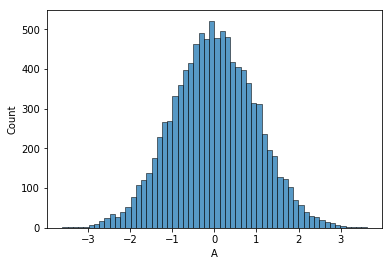

In [7]:
sns.histplot(df.A)

In [11]:
df.std()*3

A    2.991039
B    3.020015
C    2.991679
D    2.955029
dtype: float64

In [9]:
df

,A,B,C,D
0,-1.069310,-0.022525,-0.845610,-0.737196
1,-0.251695,-0.535901,1.024505,1.514567
2,-1.269066,0.782936,-0.332374,1.963683
3,1.231119,-0.759074,-1.669128,-2.046058
4,-0.089067,0.834106,-0.519878,-0.452316
...,...,...,...,...
9995,1.020509,0.606778,0.506076,-1.258729
9996,0.195978,0.330229,-0.006454,-0.955105
9997,-0.308686,-1.346395,0.616342,-0.965744
9998,1.462412,-0.562333,0.068914,-0.469630


In [15]:
exp_condition = (np.abs(df) > df.std()*3).any(axis=1)

In [21]:
exp_index = df.loc[exp_condition].index

In [18]:
# 过滤 写出正常值的过滤条件
normal_condition = (np.abs(df) < df.std()*3).all(axis=1)
df.loc[normal_condition]

,A,B,C,D
0,-1.069310,-0.022525,-0.845610,-0.737196
1,-0.251695,-0.535901,1.024505,1.514567
2,-1.269066,0.782936,-0.332374,1.963683
3,1.231119,-0.759074,-1.669128,-2.046058
4,-0.089067,0.834106,-0.519878,-0.452316
...,...,...,...,...
9995,1.020509,0.606778,0.506076,-1.258729
9996,0.195978,0.330229,-0.006454,-0.955105
9997,-0.308686,-1.346395,0.616342,-0.965744
9998,1.462412,-0.562333,0.068914,-0.469630


In [25]:
# 删除指定索引的值
# index  <==>  labels axis=0
# df.drop(index=exp_index)
# columns 指定列索引  <==> labels axis=1
df1 = df.drop(labels=exp_index, axis=0)

使用上四中位数和下四中位数进行异常值判定

In [26]:
order = pd.read_excel('电商用户数据.xlsx')

In [28]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28833 entries, 0 to 28832
Data columns (total 8 columns):
买家昵称    28833 non-null object
付款日期    28833 non-null datetime64[ns]
订单状态    28833 non-null object
实付金额    28833 non-null int64
邮费      28833 non-null int64
省份      28833 non-null object
城市      28832 non-null object
购买数量    28833 non-null int64
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 1.8+ MB


In [29]:
order.describe(percentiles=[.99])

,实付金额,邮费,购买数量
count,28833.000000,28833.000000,28833.000000
mean,126.266570,0.245240,1.510942
std,73.771696,1.386435,1.483478
min,30.000000,0.000000,1.000000
50%,115.000000,0.000000,1.000000
99%,269.000000,8.000000,6.000000
max,4225.000000,18.000000,100.000000


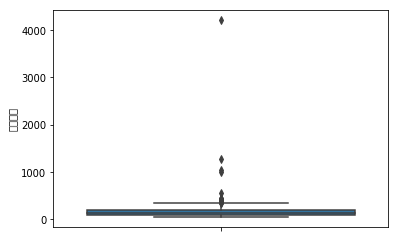

In [32]:
sns.boxplot(y=order['实付金额'])

In [37]:
# 25  75

Q1, Q3 = np.quantile(order['实付金额'], q=[0.25, 0.75])

IQR = Q3 - Q1

In [38]:
BOTTOM = Q1 - 1.5*IQR

UPPER = Q3 + 1.5*IQR

In [48]:
condition = (order['实付金额'] > UPPER).values | (order['实付金额'] < BOTTOM).values

In [50]:
exp_index = order.loc[condition].index

In [53]:
order.drop(index=exp_index).describe()

,实付金额,邮费,购买数量
count,28811.000000,28811.000000,28811.000000
mean,125.846656,0.245427,1.491444
std,68.639111,1.386947,1.072723
min,30.000000,0.000000,1.000000
25%,72.000000,0.000000,1.000000
50%,114.000000,0.000000,1.000000
75%,178.000000,0.000000,2.000000
max,336.000000,18.000000,20.000000


In [ ]:
# 处理过滤

### 处理异常值

In [ ]:
过滤

In [ ]:
删除

## 重复值处理

In [54]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,5)), columns=list('abcde'))
df

,a,b,c,d,e
0,82,63,48,90,25
1,84,52,55,38,6
2,27,45,86,8,20
3,28,90,95,83,4
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
7,17,95,19,22,81
8,86,12,56,87,18
9,11,10,99,95,54


In [55]:
df.loc[2] = df.loc[6]
df.loc[3] = df.loc[7]
df.loc[8] = df.loc[7]

In [57]:
df.loc[2, 'a'] = 100

In [58]:
df

,a,b,c,d,e
0,82,63,48,90,25
1,84,52,55,38,6
2,100,81,48,12,22
3,17,95,19,22,81
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
7,17,95,19,22,81
8,17,95,19,22,81
9,11,10,99,95,54


检查

In [61]:
# keep： 保留首次出现的重复值first还是最后一次出现的重复值last
# subse： 指定，用来判断重复值的列索引
df.duplicated(keep='last', subset=list('bcde'))

0    False
1    False
2     True
3     True
4    False
5    False
6    False
7     True
8    False
9    False
dtype: bool

过滤

In [63]:
False 0
True 1

'condition' 不是内部或外部命令，也不是可运行的程序
或批处理文件。


In [67]:
bool(1)

True

In [69]:
(condition - 1).astype(bool)

0     True
1     True
2    False
3    False
4     True
5     True
6     True
7    False
8     True
9     True
dtype: bool

In [70]:
condition = df.duplicated(keep='last', subset=list('bcde'))

df.loc[(condition - 1).astype(bool)]

,a,b,c,d,e
0,82,63,48,90,25
1,84,52,55,38,6
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
8,17,95,19,22,81
9,11,10,99,95,54


删除

In [75]:
df.drop_duplicates(subset=list('bcde'), keep='last',)

,a,b,c,d,e
0,82,63,48,90,25
1,84,52,55,38,6
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
8,17,95,19,22,81
9,11,10,99,95,54


通用的drop函数

In [74]:
exp_index = df.loc[condition].index
df.drop(index=exp_index)

,a,b,c,d,e
0,82,63,48,90,25
1,84,52,55,38,6
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
8,17,95,19,22,81
9,11,10,99,95,54


## Pandas排序与随机抽样

In [ ]:
sort_index

sort_values

sample()

take()

In [79]:
df1 = df.sort_values(by='a', ascending=False)
df1

,a,b,c,d,e
2,100,81,48,12,22
1,84,52,55,38,6
0,82,63,48,90,25
4,61,8,95,17,93
6,20,81,48,12,22
3,17,95,19,22,81
7,17,95,19,22,81
8,17,95,19,22,81
5,13,56,64,78,59
9,11,10,99,95,54


In [81]:
# 指定多条件排序
df2 = df.sort_values(by=['b','a'], ascending=True)

In [84]:
df2.sort_index(ascending=False)

,a,b,c,d,e
9,11,10,99,95,54
8,17,95,19,22,81
7,17,95,19,22,81
6,20,81,48,12,22
5,13,56,64,78,59
4,61,8,95,17,93
3,17,95,19,22,81
2,100,81,48,12,22
1,84,52,55,38,6
0,82,63,48,90,25


In [87]:
# 随机取出行或列
df.sample(n=3, axis=1)

,b,d,e
0,63,90,25
1,52,38,6
2,81,12,22
3,95,22,81
4,8,17,93
5,56,78,59
6,81,12,22
7,95,22,81
8,95,22,81
9,10,95,54


In [89]:
index = np.random.randint(0, 10, 3)
index

array([4, 9, 8])

In [92]:
df.take([1,1,2,2,3,3], axis=1)

,b,b,c,c,d,d
0,63,63,48,48,90,90
1,52,52,55,55,38,38
2,81,81,48,48,12,12
3,95,95,19,19,22,22
4,8,8,95,95,17,17
5,56,56,64,64,78,78
6,81,81,48,48,12,12
7,95,95,19,19,22,22
8,95,95,19,19,22,22
9,10,10,99,99,95,95


## 索引设置

In [ ]:
set_index

reset_index

reindex

droplevel

In [97]:
# 把指定字段设置为索引
df1 = df.set_index(keys=['a','b'])

In [103]:
df1

c   d   e
a   b             
82  63  48  90  25
84  52  55  38   6
100 81  48  12  22
17  95  19  22  81
61  8   95  17  93
13  56  64  78  59
20  81  48  12  22
17  95  19  22  81
    95  19  22  81
11  10  99  95  54

In [106]:
# 把指定索引设置为字段
df2 = df1.reset_index(level=-1)

In [120]:
# 按照指定的索引，进行索引重置（如果原始索引中存在，则选择，如果不存在，则空值填充）
df2.reindex(labels=['b','c','d','f'], axis=1)

,b,c,d,f
a,,,,
82,63,48,90,NaN
84,52,55,38,NaN
100,81,48,12,NaN
17,95,19,22,NaN
61,8,95,17,NaN
13,56,64,78,NaN
20,81,48,12,NaN
17,95,19,22,NaN
17,95,19,22,NaN


In [124]:
# 多层索引的删除
# level 指定要删除的索引层级
df1.droplevel(level=-1,axis=0)

,c,d,e
a,,,
82,48,90,25
84,55,38,6
100,48,12,22
17,19,22,81
61,95,17,93
13,64,78,59
20,48,12,22
17,19,22,81
17,19,22,81


## 映射处理

rename

In [128]:
df.rename(mapper=lambda x: str(x)+'产品', axis=1)

,a产品,b产品,c产品,d产品,e产品
0,82,63,48,90,25
1,84,52,55,38,6
2,100,81,48,12,22
3,17,95,19,22,81
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
7,17,95,19,22,81
8,17,95,19,22,81
9,11,10,99,95,54


In [133]:
dic = {
    'a':'A',
    'b':'B',
    1:'HHH',
    2:'GGG'
}

# df.rename(mapper=dic, axis=1)
df.rename(index=dic)

,a,b,c,d,e
0,82,63,48,90,25
HHH,84,52,55,38,6
GGG,100,81,48,12,22
3,17,95,19,22,81
4,61,8,95,17,93
5,13,56,64,78,59
6,20,81,48,12,22
7,17,95,19,22,81
8,17,95,19,22,81
9,11,10,99,95,54


replace

In [2]:
df = pd.DataFrame(data=np.random.randint(0,100,size=(5,4)), columns=list('ABCD'))
df

,A,B,C,D
0,72,36,77,92
1,68,78,55,91
2,39,44,87,24
3,74,72,12,95
4,41,84,37,30


In [ ]:
df.replace()

In [5]:
# list:
df.replace(to_replace=[72, 77], value=['hello', 'hello world'], inplace=True)

In [8]:
# dict:
df.replace(to_replace={68:'hehe', 78:'good'}, inplace=True)

In [11]:
df

,A,B,C,D
0,hello,36,hello world,92
1,hehe,good,55,91
2,39,44,87,24
3,74,hello,12,95
4,41,84,37,30


In [12]:
# dict: 特殊用法, 指定列替换 字典的键是列名称， 字典的值，是该列里面的要替换的值
df.replace(to_replace={'A':'hello'}, value='hELLO')

,A,B,C,D
0,hELLO,36,hello world,92
1,hehe,good,55,91
2,39,44,87,24
3,74,hello,12,95
4,41,84,37,30


In [16]:
df.replace(to_replace=39, value=np.nan)

,A,B,C,D
0,hello,36,hello world,92
1,hehe,good,55,91
2,NaN,44,87,24
3,74,hello,12,95
4,41,84,37,30


In [20]:
# regex
# r'h.*' 表示以h开头的字符串
df.replace(to_replace=r'h.*',value='H',regex=True, inplace=True)

In [21]:
df

,A,B,C,D
0,H,36,H,92
1,H,good,55,91
2,39,44,87,24
3,74,H,12,95
4,41,84,37,30


In [25]:
df.replace(to_replace='H', method='bfill', limit=1)

,A,B,C,D
0,H,36,55,92
1,39,good,55,91
2,39,44,87,24
3,74,84,12,95
4,41,84,37,30


map

In [29]:
# replace方法支持Series和DataFrame对象
df.loc[:,'A'].replace(to_replace='H', value=1)

0     1
1     1
2    39
3    74
4    41
Name: A, dtype: int64

In [30]:
# map支持Series对象
D = df['D']

In [33]:
# 模糊匹配
def score_map(x):
#     print(f'map function get a {x}')
    if x >= 60:
        return '及格'
    else:
        return '不及格'

In [36]:
D_re = D.map(score_map)

map function get a 92
map function get a 91
map function get a 24
map function get a 95
map function get a 30


In [35]:
D.map(lambda x: x>=60)

0     True
1     True
2    False
3     True
4    False
Name: D, dtype: bool

In [38]:
map_dic = {
    '及格':True,
    '不及格':False
}

In [39]:
# 精确匹配
D_re.map(map_dic)

0     True
1     True
2    False
3     True
4    False
Name: D, dtype: bool

In [54]:
map_dict2 = {
    'H':100
}

def map_dict2_function(x):
    return map_dict2.get(x, x)

df.A.map(map_dict2_function)

0    100
1    100
2     39
3     74
4     41
Name: A, dtype: int64

In [49]:
# get 键A对应的值，如果没有对应值，就默认的a
map_dict2.get('A','a')


'a'

In [53]:
map_dict2_function('H')

100